<a href="https://colab.research.google.com/github/dayannaold/dayannaold/blob/SHA256g0I8Hag%2BrGAJT7/yourname_nnn_sp26_intro_assignment_3_Wine_20_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **yourname_nnn_sp26_intro_assignment_3_Wine_20.ipynb**
---
### **Description**
- This assignment will attempt:<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ **Logistics Regression** with "Wine" dataset.  
- **Pandas DataFrame** is employed after reading **wine_data = load_wine()** from Scikit-learn
- You should run all cells until seeing the heading of "<span style="color:blue;font-size:18px;font-weight:bold"># Assignment #3 -- Start Here</span>"
- Pay attention to the outputs.
---

- Search through this notebook for the heading <span style="color:blue;font-size:18px;font-weight:bold"># Assignment #3 -- Start Here</span>.
- Start your work with the given instructions.
- Submisison details will be poste on Canvas. Most likely, <span style="color:red;font-size:15px;font-weight:bold">Sunday, May 25th by 11:00 pm.</span>

---

## Loading the dataset

In [ ]:
# Self-Sufficient Cell: Dataset Loading and Initial Inspection
import pandas as pd
from sklearn.datasets import load_wine

# 1. Load the dataset
wine_data = load_wine()

# 2. Convert to DataFrame for easier manipulation
df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
df['target'] = wine_data.target

# 3. Simple selection: Focus on two distinct features and the target
# Features: 'alcohol' and 'color_intensity'
simple_df = df[['alcohol', 'color_intensity', 'target']]

print("--- Wine Dataset Overview ---")
print(f"Feature Names: {wine_data.feature_names}")
print(f"Target Names: {wine_data.target_names}")
print("\n--- First 5 rows of our simplified selection ---")
print(simple_df.head())

# Quick check of class distribution
print("\n--- Samples per Class ---")
print(df['target'].value_counts().sort_index())

--- Wine Dataset Overview ---
Feature Names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target Names: ['class_0' 'class_1' 'class_2']

--- First 5 rows of our simplified selection ---
   alcohol  color_intensity  target
0    14.23             5.64       0
1    13.20             4.38       0
2    13.16             5.68       0
3    14.37             7.80       0
4    13.24             4.32       0

--- Samples per Class ---
target
0    59
1    71
2    48
Name: count, dtype: int64


# A. Loading the "Wine" dataset with call to LogisticRegression() using "alcohol" feature for a binary classification: class 0 and class 1

In [ ]:
# Self-Sufficient Cell: Binary Logistic Regression using 'alcohol'
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Load data
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# 2. Filter for only Class 0 and Class 1, and use only 'alcohol' feature
mask = (y == 0) | (y == 1)
X_filtered = X.loc[mask, ['alcohol']]
y_filtered = y[mask]

# 3. Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# 4. Initialize and train Logistic Regression
# We use 'lbfgs' solver as it is standard for small datasets
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("--- Binary Classification Results (Class 0 vs Class 1) ---")
print(f"Feature used: Alcohol")
print(f"Accuracy Score: {accuracy:.2%}")
print("\n--- Confusion Matrix ---")
print(conf_matrix)
print("\nInterpretation:")
print(f"True Negatives (Class 0): {conf_matrix[0,0]}")
print(f"False Positives (Predicted 1, actually 0): {conf_matrix[0,1]}")
print(f"False Negatives (Predicted 0, actually 1): {conf_matrix[1,0]}")
print(f"True Positives (Class 1): {conf_matrix[1,1]}")

--- Binary Classification Results (Class 0 vs Class 1) ---
Feature used: Alcohol
Accuracy Score: 100.00%

--- Confusion Matrix ---
[[13  0]
 [ 0 13]]

Interpretation:
True Negatives (Class 0): 13
False Positives (Predicted 1, actually 0): 0
False Negatives (Predicted 0, actually 1): 0
True Positives (Class 1): 13


### 1. Adding the plotting code for the confusion matrix

Accuracy with 'alcohol' feature: 100.00%
--- Binary Classification Results (Class 0 vs Class 1) ---
Feature used: Alcohol
Accuracy Score: 100.00%

--- Confusion Matrix ---
[[13  0]
 [ 0 13]]

Interpretation:
True Negatives (Class 0): 13
False Positives (Predicted 1, actually 0): 0
False Negatives (Predicted 0, actually 1): 0
True Positives (Class 1): 13


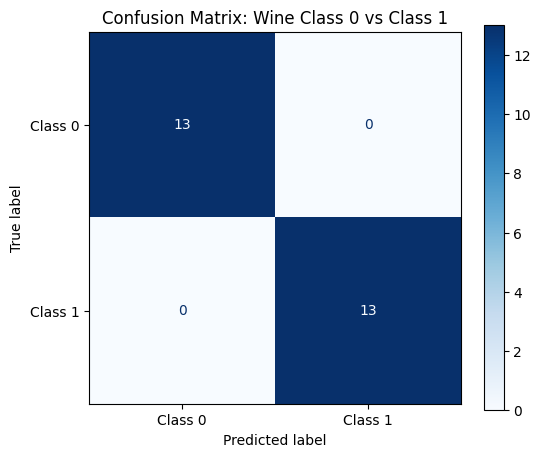

In [ ]:
# Self-Sufficient Cell: Binary Logistic Regression with Confusion Matrix Plot
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 1. Load data
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# 2. Filter for only Class 0 and Class 1, and use only 'alcohol' feature
mask = (y == 0) | (y == 1)
X_filtered = X.loc[mask, ['alcohol']]
y_filtered = y[mask]

# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# 4. Initialize and train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluation and Visualization
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy with 'alcohol' feature: {accuracy:.2%}")

### Copy and update previous code
print("--- Binary Classification Results (Class 0 vs Class 1) ---")
print(f"Feature used: Alcohol")
print(f"Accuracy Score: {accuracy:.2%}")
print("\n--- Confusion Matrix ---")
print(conf_matrix)
print("\nInterpretation:")
print(f"True Negatives (Class 0): {conf_matrix[0,0]}")
print(f"False Positives (Predicted 1, actually 0): {conf_matrix[0,1]}")
print(f"False Negatives (Predicted 0, actually 1): {conf_matrix[1,0]}")
print(f"True Positives (Class 1): {conf_matrix[1,1]}")

# Plotting the Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                              display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title("Confusion Matrix: Wine Class 0 vs Class 1")
plt.show()

### 2. Adding Precision, Recall, F1-Score, Classification Report

--- Binary Classification Results (Class 0 vs Class 1) ---
Feature used: Alcohol
Accuracy Score:  100.00%
Precision Score: 100.00%
Recall Score:    100.00%
F1-Score:        100.00%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        13
     Class 1       1.00      1.00      1.00        13

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26


--- Confusion Matrix Interpretation ---
True Negatives (Class 0): 13
False Positives (Predicted 1, actually 0): 0
False Negatives (Predicted 0, actually 1): 0
True Positives (Class 1): 13


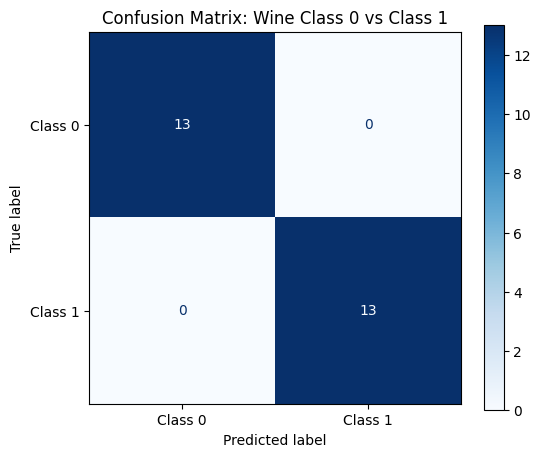

In [ ]:
# Self-Sufficient Cell: Binary Logistic Regression with Comprehensive Metrics
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# 1. Load data
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# 2. Filter for only Class 0 and Class 1, and use only 'alcohol' feature
mask = (y == 0) | (y == 1)
X_filtered = X.loc[mask, ['alcohol']]
y_filtered = y[mask]

# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# 4. Initialize and train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluation and Visualization
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("--- Binary Classification Results (Class 0 vs Class 1) ---")
print(f"Feature used: Alcohol")
print(f"Accuracy Score:  {accuracy:.2%}")
print(f"Precision Score: {precision:.2%}")
print(f"Recall Score:    {recall:.2%}")
print(f"F1-Score:        {f1:.2%}")

print("\n--- Detailed Classification Report ---")
# Using target_names from the dataset for clarity
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

print("\n--- Confusion Matrix Interpretation ---")
print(f"True Negatives (Class 0): {conf_matrix[0,0]}")
print(f"False Positives (Predicted 1, actually 0): {conf_matrix[0,1]}")
print(f"False Negatives (Predicted 0, actually 1): {conf_matrix[1,0]}")
print(f"True Positives (Class 1): {conf_matrix[1,1]}")

# Plotting the Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                              display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title("Confusion Matrix: Wine Class 0 vs Class 1")
plt.show()

GR5:
When evaluating a model like your wine classifier, Accuracy can be misleading, especially if the classes are unbalanced. These three metrics—Precision, Recall, and the F1-Score—provide a deeper look into how the model is actually making its mistakes.
________________________________________
1. Precision (The "Quality" Metric)
Definition: Precision measures the accuracy of positive predictions. It answers the question: “Of all the wines predicted to be Class 1, how many were actually Class 1?”
$$Precision = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}$$

Precision=  TP/(TP+FP)

	Why use it: Use Precision when the cost of a False Positive is high.
	Example: If you are labeling a wine as "Premium" (Class 1) to sell at a higher price, a False Positive means you’re accidentally selling cheap wine as premium, which hurts your brand's reputation. High precision ensures that when the model says "Class 1," it is very likely correct.
________________________________________
2. Recall (The "Quantity" Metric)
Definition: Recall (also called Sensitivity) measures the ability of a model to find all the positive units. It answers the question: “Of all the actual Class 1 wines in the dataset, how many did the model correctly identify?”
$$Recall = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$

Recall=  TP/(TP+FN)


	Why use it: Use Recall when the cost of a False Negative is high.
	Example: If Class 1 wine contained a specific allergen, you would want a Recall of 100%. A False Negative in this case means an allergic person drinks the wine because the model failed to flag it. You’d rather over-identify (lower precision) than miss a single case (high recall).
________________________________________
3. F1-Score (The "Balance" Metric)
Definition: The F1-Score is the harmonic mean of Precision and Recall. It combines both into a single number to provide a balanced view.
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

F1_Score=2×(Precision ×Recall)/(Precision+Recall)
	Why use it: In many real-world scenarios, there is a trade-off between Precision and Recall (improving one often hurts the other). The F1-Score is the best metric to use if you need a balance between the two and especially if you have uneven class distributions.
	Example: If your wine dataset had 100 bottles of Class 0 and only 5 bottles of Class 1, a model could get 95% accuracy just by guessing "Class 0" every time. However, its Precision and Recall for Class 1 would be 0. The F1-Score would reveal that this model is actually useless for finding Class 1.
________________________________________
Summary Table for Quick ReferenceMetricFocusKey QuestionGoalPrecisionReliability"Is this prediction right?"Minimize False PositivesRecallCoverage"Did I miss any?"Minimize False Negatives

![image.png](attachment:9858c4cf-a25b-4241-aab5-cd395cf5602d.png)


# TESTING 01 START
## Redo/Restart --> Binary Classification with Class 0 and Class 1
### 1. Code for Accuracy, Confusion Matrix, Precision, Recall, and F1-Score.

--- Logistic Regression Performance Metrics ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

--- Scikit-Learn Classification Report ---
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        13
     Class 1       1.00      1.00      1.00        13

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



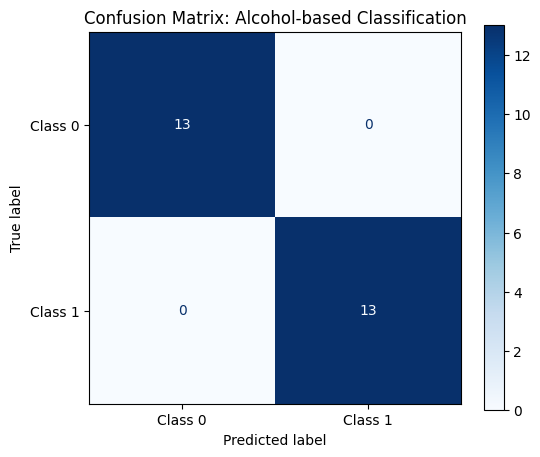

In [ ]:
# Self-Sufficient Cell: Logistic Regression with Full Metric Suite
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# 1. Load and filter data (Class 0 and 1, Alcohol feature)
wine = load_wine()
feature_cols = ['alcohol']
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target
mask = (y == 0) | (y == 1)
X_filtered = X.loc[mask, feature_cols]
y_filtered = y[mask]

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# 3. Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Predictions
y_pred = model.predict(X_test)

# 5. Calculate Numerical Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# 6. Display Results
print("--- Logistic Regression Performance Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\n--- Scikit-Learn Classification Report ---")
# This report provides metrics for each class specifically
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# 7. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                              display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title("Confusion Matrix: Alcohol-based Classification")
plt.show()

### 2. Adding back the plotting code

--- Logistic Regression Metrics ---
Accuracy:  1.0000 | Precision: 1.0000
Recall:    1.0000 | F1-Score:  1.0000

--- Classification Report ---
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        13
     Class 1       1.00      1.00      1.00        13

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



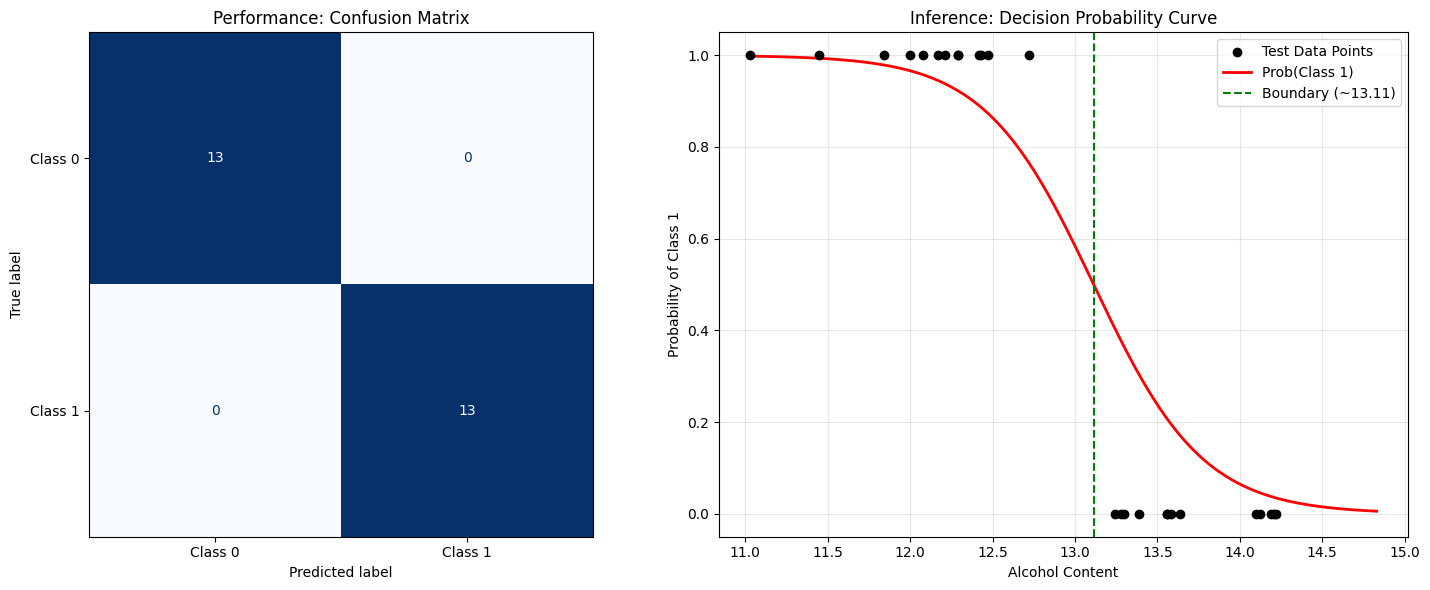

In [ ]:
# Self-Sufficient Cell: Full Logistic Regression Suite (Metrics + Inference Plot)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# 1. Load and Filter Data (Classes 0 & 1, 'alcohol' feature)
wine = load_wine()
feature_cols = ['alcohol']
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

mask = (y == 0) | (y == 1)
X_filtered = X.loc[mask, feature_cols]
y_filtered = y[mask]

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# 3. Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Model Predictions & Inference
y_pred = model.predict(X_test)

# Generate points for the smooth probability curve (Fixed to avoid UserWarning)
raw_range = np.linspace(X_filtered.min(), X_filtered.max(), 300).reshape(-1, 1)
X_range_df = pd.DataFrame(raw_range, columns=feature_cols)
probabilities = model.predict_proba(X_range_df)[:, 1]

# 5. Numerical Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# --- RESULTS OUTPUT ---
print("--- Logistic Regression Metrics ---")
print(f"Accuracy:  {accuracy:.4f} | Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f} | F1-Score:  {f1:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# 6. Visualization: Confusion Matrix and Inference Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, ax=ax1, colorbar=False)
ax1.set_title("Performance: Confusion Matrix")

# Plot 2: Inference Probability Curve
ax2.scatter(X_test, y_test, color='black', label='Test Data Points', zorder=5)
ax2.plot(X_range_df, probabilities, color='red', linewidth=2, label='Prob(Class 1)')

# Decision Boundary Visualization
boundary_val = X_range_df.iloc[np.argmin(np.abs(probabilities - 0.5))].values[0]
ax2.axvline(x=boundary_val, color='green', linestyle='--', label=f'Boundary (~{boundary_val:.2f})')

ax2.set_title("Inference: Decision Probability Curve")
ax2.set_xlabel("Alcohol Content")
ax2.set_ylabel("Probability of Class 1")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.0 plotting larger images

--- Logistic Regression Metrics ---
Accuracy:  1.0000 | Precision: 1.0000
Recall:    1.0000 | F1-Score:  1.0000

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        13
     Class 1       1.00      1.00      1.00        13

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



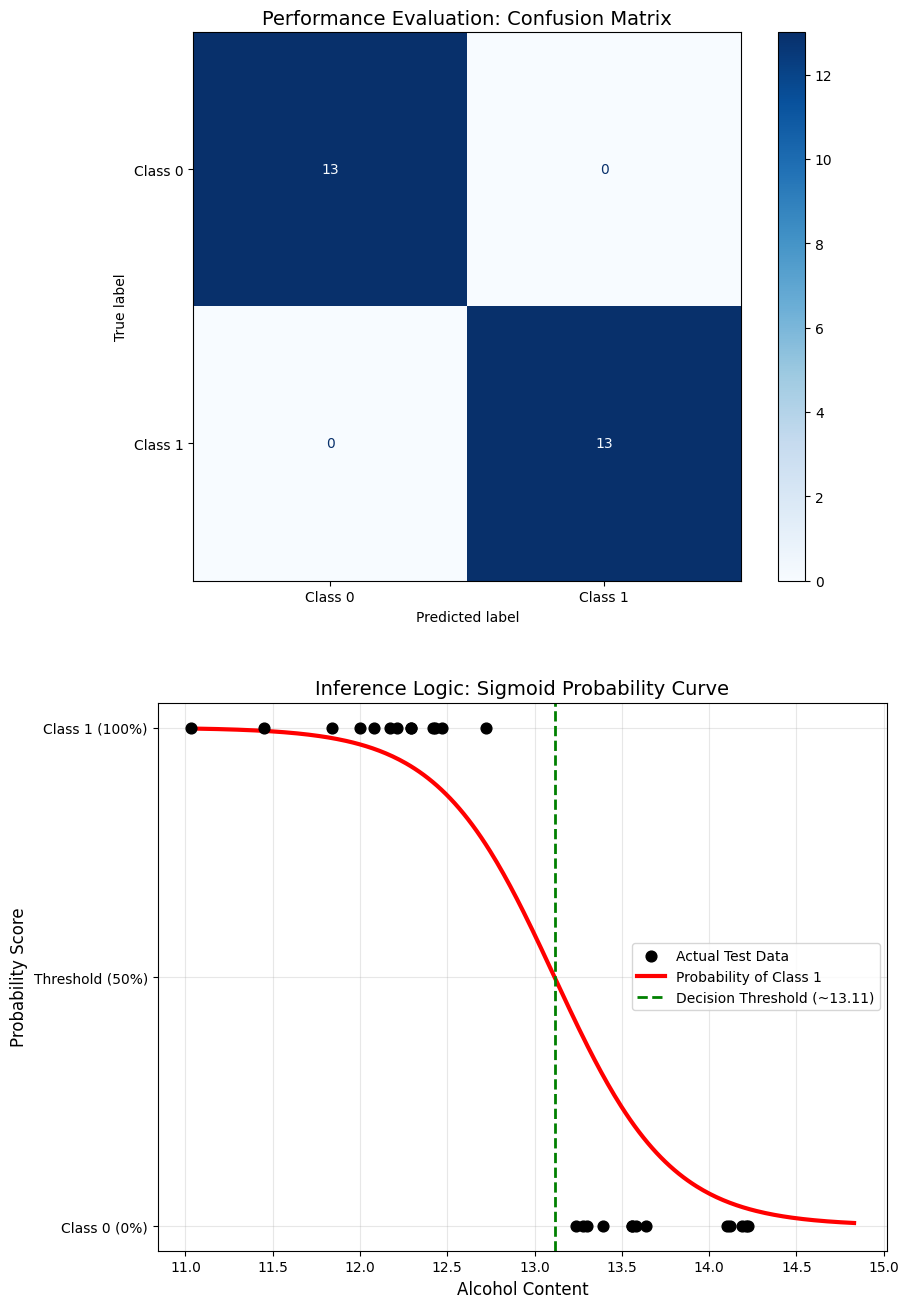

In [ ]:
# Self-Sufficient Cell: Full Logistic Regression Suite (Stacked Visualizations)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# 1. Load and Filter Data (Classes 0 & 1, 'alcohol' feature)
wine = load_wine()
feature_cols = ['alcohol']
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

mask = (y == 0) | (y == 1)
X_filtered = X.loc[mask, feature_cols]
y_filtered = y[mask]

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# 3. Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Model Predictions & Inference
y_pred = model.predict(X_test)

# Generate smooth probability curve data
raw_range = np.linspace(X_filtered.min(), X_filtered.max(), 300).reshape(-1, 1)
X_range_df = pd.DataFrame(raw_range, columns=feature_cols)
probabilities = model.predict_proba(X_range_df)[:, 1]

# 5. Numerical Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# --- TEXT RESULTS ---
print("--- Logistic Regression Metrics ---")
print(f"Accuracy:  {accuracy:.4f} | Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f} | F1-Score:  {f1:.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# 6. Visualization: Large Vertical Layout
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 14)) # 2 Rows, 1 Column

# Plot 1: Full-Size Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, ax=ax1)
ax1.set_title("Performance Evaluation: Confusion Matrix", fontsize=14)

# Plot 2: Full-Size Inference Probability Curve
ax2.scatter(X_test, y_test, color='black', s=60, label='Actual Test Data', zorder=5)
ax2.plot(X_range_df, probabilities, color='red', linewidth=3, label='Probability of Class 1')

# Decision Boundary Visualization
boundary_val = X_range_df.iloc[np.argmin(np.abs(probabilities - 0.5))].values[0]
ax2.axvline(x=boundary_val, color='green', linestyle='--', linewidth=2,
            label=f'Decision Threshold (~{boundary_val:.2f})')

ax2.set_title("Inference Logic: Sigmoid Probability Curve", fontsize=14)
ax2.set_xlabel("Alcohol Content", fontsize=12)
ax2.set_ylabel("Probability Score", fontsize=12)
ax2.set_yticks([0, 0.5, 1.0])
ax2.set_yticklabels(['Class 0 (0%)', 'Threshold (50%)', 'Class 1 (100%)'])
ax2.legend(loc='center right')
ax2.grid(True, alpha=0.3)

plt.tight_layout(pad=4.0) # Adds spacing between the two plots
plt.show()

# TESTING 01 END

In [ ]:
110 %

# TESTING 02 START

# Updating code with (1) Using 2 features of "alcohol" and "flavanoids", and (2) Classifying using Class 0 and Class 1.

--- Logistic Regression Metrics (2 Features) ---
Features: ['alcohol', 'flavanoids']
Accuracy:  1.0000 | Precision: 1.0000
Recall:    1.0000 | F1-Score:  1.0000

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        13
     Class 1       1.00      1.00      1.00        13

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



C:\python\install\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


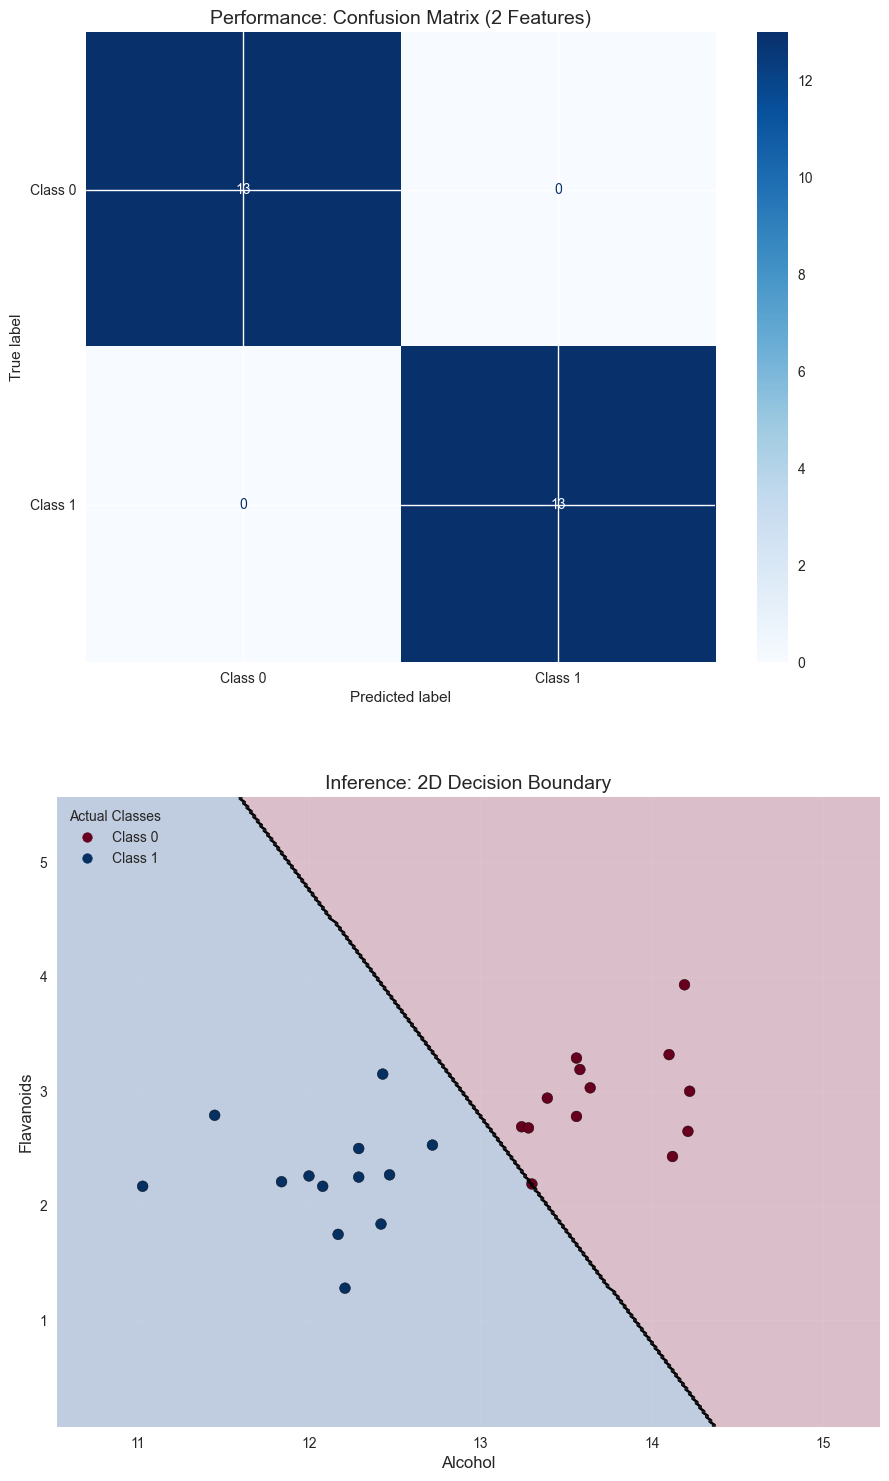

In [ ]:
# Self-Sufficient Cell: 2-Feature Logistic Regression (Alcohol & Flavanoids)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# 1. Load and Filter Data (Classes 0 & 1, 2 Features)
wine = load_wine()
feature_cols = ['alcohol', 'flavanoids']
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

mask = (y == 0) | (y == 1)
X_filtered = X.loc[mask, feature_cols]
y_filtered = y[mask]

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# 3. Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Predictions
y_pred = model.predict(X_test)

# 5. Numerical Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# --- TEXT RESULTS ---
print("--- Logistic Regression Metrics (2 Features) ---")
print(f"Features: {feature_cols}")
print(f"Accuracy:  {accuracy:.4f} | Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f} | F1-Score:  {f1:.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# 6. Visualization: Vertical Layout
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 16))

# Plot 1: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, ax=ax1)
ax1.set_title("Performance: Confusion Matrix (2 Features)", fontsize=14)

# Plot 2: 2D Decision Boundary (Inference Visualization)
# Create a mesh grid to plot the decision regions
h = .02  # step size in the mesh
x_min, x_max = X_filtered.iloc[:, 0].min() - 0.5, X_filtered.iloc[:, 0].max() + 0.5
y_min, y_max = X_filtered.iloc[:, 1].min() - 0.5, X_filtered.iloc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict across the entire mesh
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision regions
ax2.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.RdBu)
ax2.contour(xx, yy, Z, colors='k', linewidths=0.5) # The actual boundary line

# Scatter plot of test data points
scatter = ax2.scatter(X_test['alcohol'], X_test['flavanoids'], c=y_test,
            edgecolors='k', s=60, cmap=plt.cm.RdBu, label='Test Samples')

ax2.set_title("Inference: 2D Decision Boundary", fontsize=14)
ax2.set_xlabel("Alcohol", fontsize=12)
ax2.set_ylabel("Flavanoids", fontsize=12)
ax2.grid(True, alpha=0.2)

# Handle Legend for scatter classes
handles, labels = scatter.legend_elements()
ax2.legend(handles, ['Class 0', 'Class 1'], loc="upper left", title="Actual Classes")

plt.tight_layout(pad=5.0)
plt.show()

## Fixing the warning

--- Logistic Regression Metrics (2 Features) ---
Features: ['alcohol', 'flavanoids']
Accuracy:  1.0000 | Precision: 1.0000
Recall:    1.0000 | F1-Score:  1.0000

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        13
     Class 1       1.00      1.00      1.00        13

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



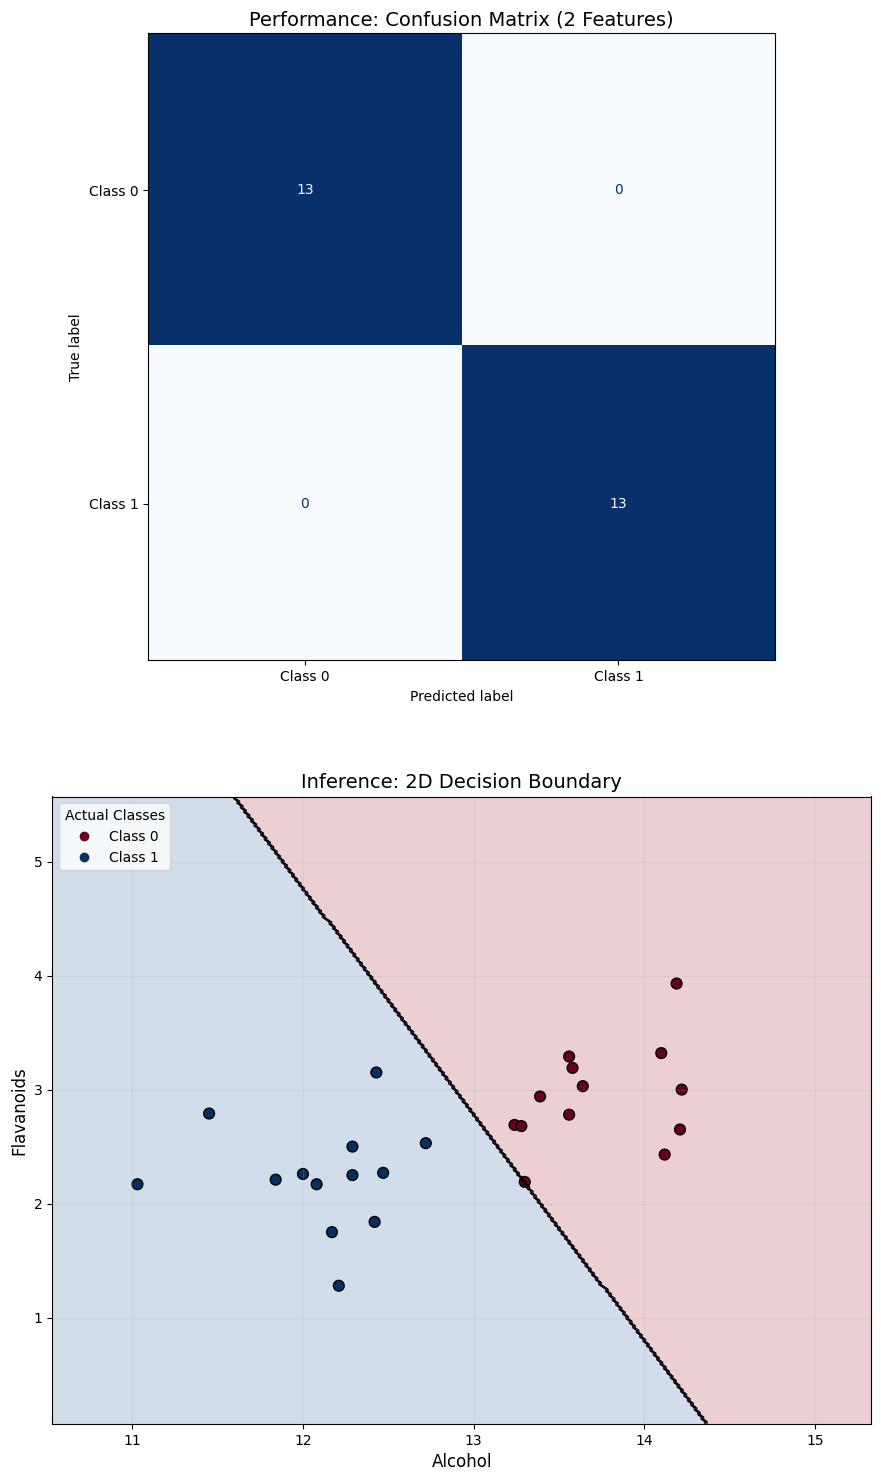

In [ ]:
# Self-Sufficient Cell: 2-Feature Logistic Regression (Alcohol & Flavanoids)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# 1. Load and Filter Data (Classes 0 & 1, 2 Features)
wine = load_wine()
feature_cols = ['alcohol', 'flavanoids']
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

mask = (y == 0) | (y == 1)
X_filtered = X.loc[mask, feature_cols]
y_filtered = y[mask]

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# 3. Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Predictions
y_pred = model.predict(X_test)

# 5. Numerical Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# --- TEXT RESULTS ---
print("--- Logistic Regression Metrics (2 Features) ---")
print(f"Features: {feature_cols}")
print(f"Accuracy:  {accuracy:.4f} | Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f} | F1-Score:  {f1:.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# 6. Visualization: Vertical Layout
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 16))

# Plot 1: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Class 0', 'Class 1'])
# Added colorbar=False to ensure clean subplot layouts without warning constraints
disp.plot(cmap=plt.cm.Blues, ax=ax1, colorbar=False)
ax1.set_title("Performance: Confusion Matrix (2 Features)", fontsize=14)

# Plot 2: 2D Decision Boundary (Inference Visualization)
h = .02  # step size in the mesh
x_min, x_max = X_filtered.iloc[:, 0].min() - 0.5, X_filtered.iloc[:, 0].max() + 0.5
y_min, y_max = X_filtered.iloc[:, 1].min() - 0.5, X_filtered.iloc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# --- THE FIX ---
# Instead of passing raw NumPy arrays, map them into a DataFrame with feature names
mesh_data = np.c_[xx.ravel(), yy.ravel()]
mesh_df = pd.DataFrame(mesh_data, columns=feature_cols)

# Predict across the named DataFrame mesh
Z = model.predict(mesh_df)
Z = Z.reshape(xx.shape)

# Plot the decision regions
ax2.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.RdBu)
ax2.contour(xx, yy, Z, colors='k', linewidths=0.5) # The actual boundary line

# Scatter plot of test data points
scatter = ax2.scatter(X_test['alcohol'], X_test['flavanoids'], c=y_test,
                      edgecolors='k', s=60, cmap=plt.cm.RdBu, label='Test Samples')

ax2.set_title("Inference: 2D Decision Boundary", fontsize=14)
ax2.set_xlabel("Alcohol", fontsize=12)
ax2.set_ylabel("Flavanoids", fontsize=12)
ax2.grid(True, alpha=0.2)

# Handle Legend for scatter classes
handles, labels = scatter.legend_elements()
ax2.legend(handles, ['Class 0', 'Class 1'], loc="upper left", title="Actual Classes")

plt.tight_layout(pad=5.0)
plt.show()

# TESTING 02 END

# **TESTING 03 START**

# Binary classification
## Setup with
- ### (1) Using 2 features of "alcohol" and "flavanoids"
- ### (2) Classifying using Class 0 and Class 2, and
- ### (3) LogisticRegression()


### For Assignment #3 hint, use this setup.

--- Logistic Regression Metrics (Classes 0 & 2) ---
Accuracy: 1.0000

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        12
     Class 2       1.00      1.00      1.00        10

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



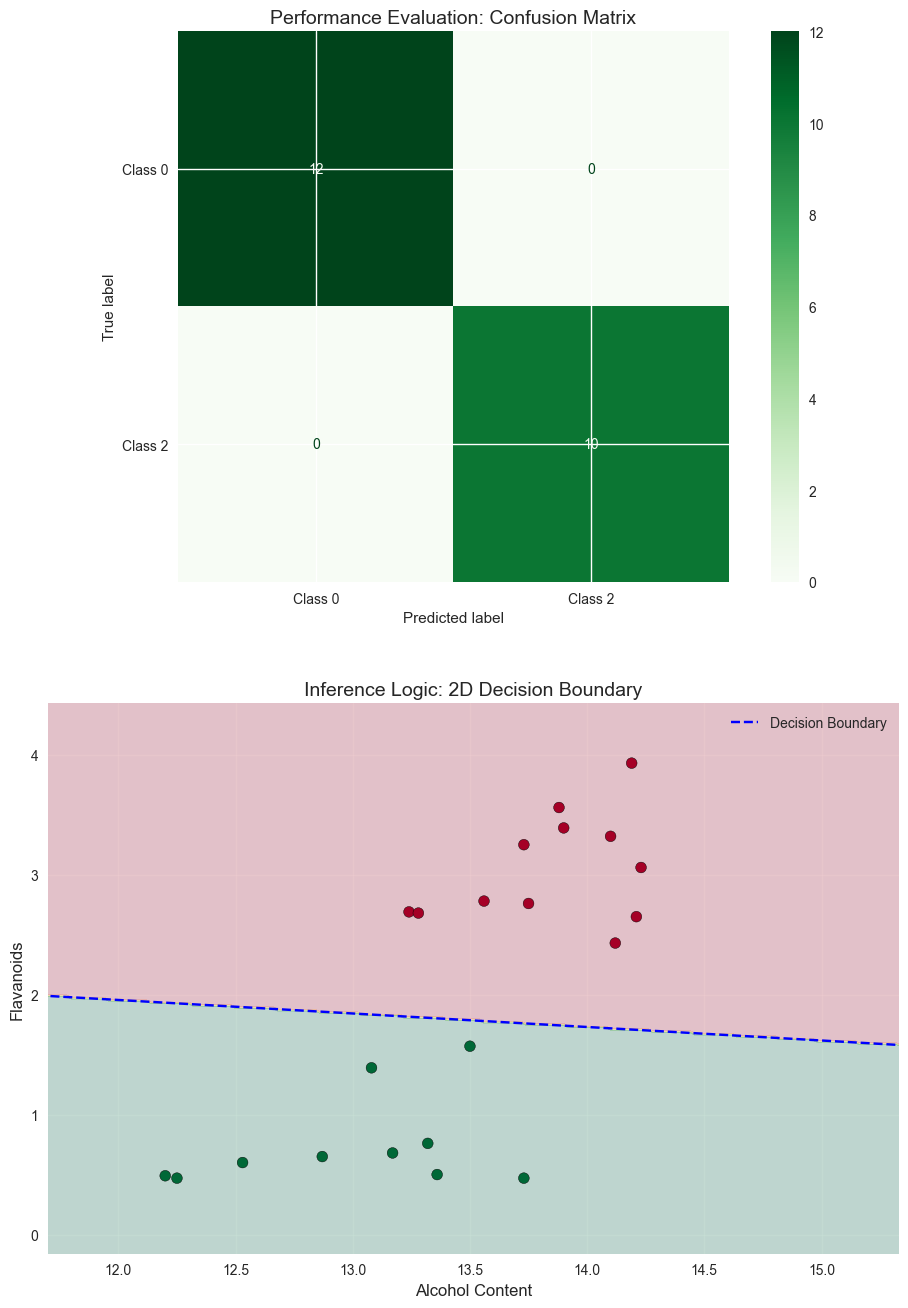

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report
)

# 1. Load and Filter Data (Classes 0 & 2, 'alcohol' & 'flavanoids')
wine = load_wine()
feature_cols = ['alcohol', 'flavanoids']
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# Update: Masking for Class 0 and Class 2
mask = (y == 0) | (y == 2)
X_filtered = X.loc[mask, feature_cols]
y_filtered = y[mask]

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# 3. Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Model Predictions
y_pred = model.predict(X_test)

# 5. Numerical Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("--- Logistic Regression Metrics (Classes 0 & 2) ---")
print(f"Accuracy: {accuracy:.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 2']))

# 6. Visualization: Decision Boundary
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 14))

# Plot 1: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Class 0', 'Class 2'])
disp.plot(cmap=plt.cm.Greens, ax=ax1)
ax1.set_title("Performance Evaluation: Confusion Matrix", fontsize=14)

# Plot 2: 2D Decision Boundary
# Create a mesh grid for the background color
h = .02  # step size in the mesh
x_min, x_max = X_filtered.iloc[:, 0].min() - 1, X_filtered.iloc[:, 0].max() + 1
y_min, y_max = X_filtered.iloc[:, 1].min() - 1, X_filtered.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict across the mesh grid
#Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
#Z = Z.reshape(xx.shape)

# --- FIXED SECTION ---
# Predict across the mesh grid
# Wrap the coordinates in a DataFrame to match the training data format
mesh_data = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=feature_cols)
Z = model.predict(mesh_data)
Z = Z.reshape(xx.shape)
# ----------------------

# Plot the decision regions
ax2.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.RdYlGn)
ax2.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.RdYlGn, s=60)

# Extracting the boundary line equation: w0*x + w1*y + b = 0  => y = -(w0/w1)x - (b/w1)
b = model.intercept_[0]
w0, w1 = model.coef_[0]
x_vals = np.array([x_min, x_max])
y_vals = -(w0 / w1) * x_vals - (b / w1)
ax2.plot(x_vals, y_vals, '--', color='blue', label='Decision Boundary')

ax2.set_title("Inference Logic: 2D Decision Boundary", fontsize=14)
ax2.set_xlabel("Alcohol Content", fontsize=12)
ax2.set_ylabel("Flavanoids", fontsize=12)
ax2.set_xlim(x_min + 0.5, x_max - 0.5)
ax2.set_ylim(y_min + 0.5, y_max - 0.5)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout(pad=4.0)
plt.show()

# TESTING 03 END

<span style="color:blue;font-size:28px;font-weight:bold"># Assignment #3 -- Start Here</span>

- **Submission information will be posted on Canvas.** Most likely, Sunday, May 25th by 11:00 pm.
- **Check for Canvas frequently for posts.**
- **Additional Description of the "Wine" dataset is given at the end of this notebook.**

---
**Wine Dataset Overview** -- 13 Features and 3 Targets<br>
**Feature Names:** ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']<br><br>**Target Names:** ['class_0', 'class_1', 'class_2']
<br>

---
## **Your tasks to complete:**

- There will be 4 tasks.
- Looking up your own **Student ID**
- Notice the last 3 digits of your ID (for example, 234 --> student_id = 234)
- Read the instructions carefully.
- Save your notebook as: **yourname_nnn_sp26_intro_assignment_3_Wine_15.ipynb** and replace **nnn** with your last 3 digits of your student ID; e.g., **john_smith_234_sp26_intro_assignment_3_Wine_15.ipynb**
- Again, detailed Submission will be posted on Canvas. Most likely, Sunday, May 25th by 11:00pm.<br><br>
- **Task #1:**<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ **Find modulo(student_id);** e.g., student_id % 3<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ **Hard-code student_id** with the correct value if you should (like)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;■ if (student_id % 3) == 0, then choose targets 'class 0' and 'class 1'<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;■ if (student_id % 3) == 1, then choose targets 'class 1' and 'class 2'<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;■ if (student_id % 3) == 2, then choose targets 'class 2'and 'class 0'<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ **Done Task #1**<br>
- **Task #2:**<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ There are 13 features. You need to choose 3 pairs from these 13 (total of 6 features).<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ Set up 3 self-sufficient cells using the setp from "TESTING 03".<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ For each cell using the same two selected classes above and one pair of features.<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ For each cell, update the text information and details appropriately.<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ For all 3 cells, keep the percentage of 80/20 and seed of 42.<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ **Run these self-sufficient cells.**<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ **Done Task #2**
- **Task #3 -- THE GAME**<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ Keeping the targets being the same, the game now is to find **a pair of features that produces some TP and/or FN**.<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ Your task is to get that pair of features. You can do this task by patiently enough to select the combinations from the 13 features.<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ **For each pair of selected features, please create a new self- sufficient cell** and<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;■ Update with proper information.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;■ Tun and pay attention to the report/display.<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ If not successful early, please try with "at least 12 additional pairs of features** before stopping (as no imperfect report/display can be found).<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ **Done Task #3!**
- **Task #4:**<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ Write a **Summarized Report** of your comparison+effort and submit as PDF.<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ For submisison, email the notebook (*.ipynb) and PDF.<br>
&nbsp;&nbsp;&nbsp;&nbsp;■ **DONE with Assignment #3!**

---

<span style="color:blue;font-size:24px;font-weight:bold">Assignment #3 -- Finish Here!</span>

## **Wine Dataset:** Details

It is a fantastic step up from the Iris dataset because it offers a bit more complexity with more features and slightly more nuanced class separations, making it perfect for demonstrating why we might choose specific features for a model.

Here is a detailed breakdown of the dataset to share with your students before they dive into the code.
The Scikit-learn Wine Recognition Dataset

The Wine dataset is a classic multi-class classification dataset. It is the result of a chemical analysis of wines grown in the same region in Italy by three different cultivators.<br><br>
**1. Dataset Overview**

    Samples Total: 178

    Dimensionality: 13 numeric, predictive attributes

    Classes: 3 (represented as Class 0, Class 1, and Class 2)

    Target: The specific cultivator (type of wine)

**2. The Features (Chemical Analysis)**

The 13 features represent the chemical fingerprints of the wine. When teaching, it is often helpful to point out that these are all continuous values, which is why they work so well for Logistic Regression:

    Alcohol

    Malic acid

    Ash

    Alcalinity of ash

    Magnesium

    Total phenols

    Flavanoids

    Nonflavanoid phenols

    Proanthocyanins

    Color intensity

    Hue

    OD280/OD315 of diluted wines (Protein content indicator)

    Proline (An amino acid)

**3. Class Distribution**

The classes are relatively well-balanced, though not perfectly equal:

    Class 0: 59 samples

    Class 1: 71 samples

    Class 2: 48 samples

**4. Key Learning Opportunities for Students**

    Feature Scaling: Unlike the Iris dataset, the scales here vary wildly. For example, Ash values are around 2.0, while Magnesium can be over 100 and Proline can exceed 1,000. This is a perfect moment to discuss why normalization or standardization is necessary for many ML algorithms.

    Feature Selection: Not all 13 features are equally "predictive." Students can explore which features (like Alcohol or Color Intensity) provide the clearest separation between the three wine types.

    Multi-class Logistic Regression: Since there are three classes, this moves students beyond binary classification into "One-vs-Rest" (OvR) or "Multinomial" logic.
---


**5. For Logistic Regression:** The Wine Dataset<br>
Since you have already used Iris, the Wine dataset is the logical "next step." It is slightly more complex than Iris but still very manageable.

What it is:<br>
- Results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars. It has 178 samples and 13 features.
---


![image.png](attachment:d20470f5-8c4a-4221-ba19-78760de144ed.png)



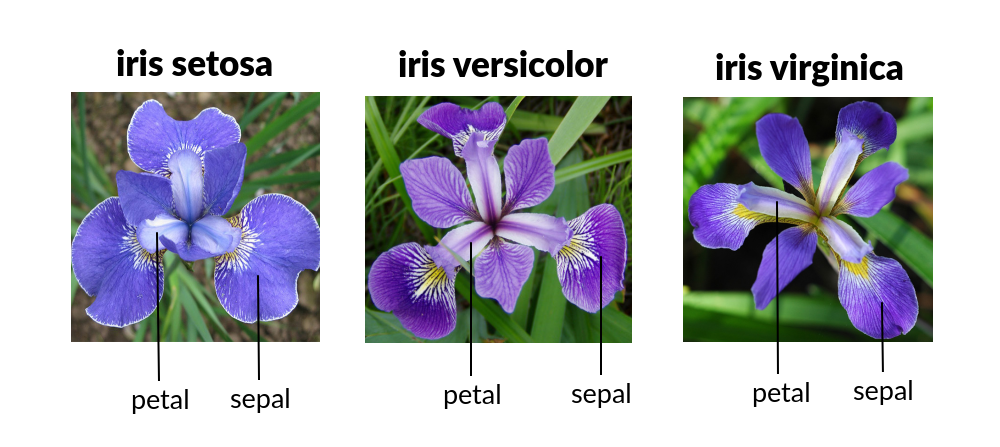
